In [1]:
# Λήψη και εκτύπωση dataframe
import pandas as pd
from pymongo import MongoClient
import matplotlib.pyplot as plt

# Σύνδεση στη MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["wsn_database"]
collection = db["sensor_data"]

# Φόρτωση όλων των δεδομένων -> ΠΡΟΣΘΕΣΑΜΕ ΤΟ "hum_raw": 1 ΕΔΩ!
docs = list(collection.find({}, {
    "_id": 0, 
    "timestamp": 1, 
    "temperature_c": 1, 
    "humidity_pct": 1, 
    "sample_num": 1,
    "hum_raw": 1
}))

df = pd.DataFrame(docs)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Σταθερές αισθητήρα SHT11
t1 = 0.01
t2 = 0.00008

# Υπολογίζουμε τη διορθωμένη υγρασία (RH_true) - Τώρα το df["hum_raw"] υπάρχει κανονικά!
df["humidity_compensated"] = (df["temperature_c"] - 25) * (t1 + t2 * df["hum_raw"]) + df["humidity_pct"]

# Περιορίζουμε τις τιμές στο [0, 100] και στρογγυλοποιούμε
df["humidity_compensated"] = df["humidity_compensated"].clip(0.0, 100.0).round(2)

print("=== ΣΥΓΚΡΙΣΗ ΑΠΛΗΣ ΚΑΙ ΔΙΟΡΘΩΜΕΝΗΣ ΥΓΡΑΣΙΑΣ ===")
print(df[["timestamp", "temperature_c", "humidity_pct", "humidity_compensated"]].head())
print(f"\nΣυνολικές μετρήσεις: {len(df)}")
print(df)

=== ΣΥΓΚΡΙΣΗ ΑΠΛΗΣ ΚΑΙ ΔΙΟΡΘΩΜΕΝΗΣ ΥΓΡΑΣΙΑΣ ===
                timestamp  temperature_c  humidity_pct  humidity_compensated
0 2026-05-04 14:35:48.071          33.49         26.39                 27.02
1 2026-05-04 14:36:07.604          33.48         26.29                 26.92
2 2026-05-04 14:36:27.131          33.51         26.43                 27.06
3 2026-05-04 14:36:46.668          33.58         26.29                 26.92
4 2026-05-04 14:37:06.197          33.54         26.29                 26.92

Συνολικές μετρήσεις: 9989
                   timestamp  sample_num  hum_raw  temperature_c  \
0    2026-05-04 14:35:48.071          57      803          33.49   
1    2026-05-04 14:36:07.604          58      800          33.48   
2    2026-05-04 14:36:27.131          59      804          33.51   
3    2026-05-04 14:36:46.668          60      800          33.58   
4    2026-05-04 14:37:06.197          61      800          33.54   
...                      ...         ...      ...      

=== ΣΤΑΤΙΣΤΙΚΗ ΑΝΑΛΥΣΗ ΠΡΙΝ ΤΗΝ ΑΦΑΙΡΕΣΗ===
       temperature_c  humidity_compensated
count    9989.000000           9989.000000
mean        3.485947             39.444563
std        31.706300              3.559416
min       -32.660000             26.630000
25%       -32.580000             37.960000
50%        30.030000             39.230000
75%        31.480000             42.230000
max        34.500000             52.410000
Πριν τον καθαρισμό: 9989 μετρήσεις
=== ΣΤΑΤΙΣΤΙΚΗ ΑΝΑΛΥΣΗ ΜΕΤΑ ΤΗΝ ΑΦΑΙΡΕΣΗ===
       temperature_c  humidity_compensated
count    5631.000000           5631.000000
mean       31.368416             41.440719
std         1.082437              2.895581
min        29.040000             26.630000
25%        30.540000             39.730000
50%        31.310000             41.860000
75%        31.990000             43.295000
max        34.500000             52.410000
Μετά τον καθαρισμό (θερμοκρασία): 5631 μετρήσεις
Αφαιρέθηκαν: 4358 outliers
Μετά τον καθαρισμό (υγρασία

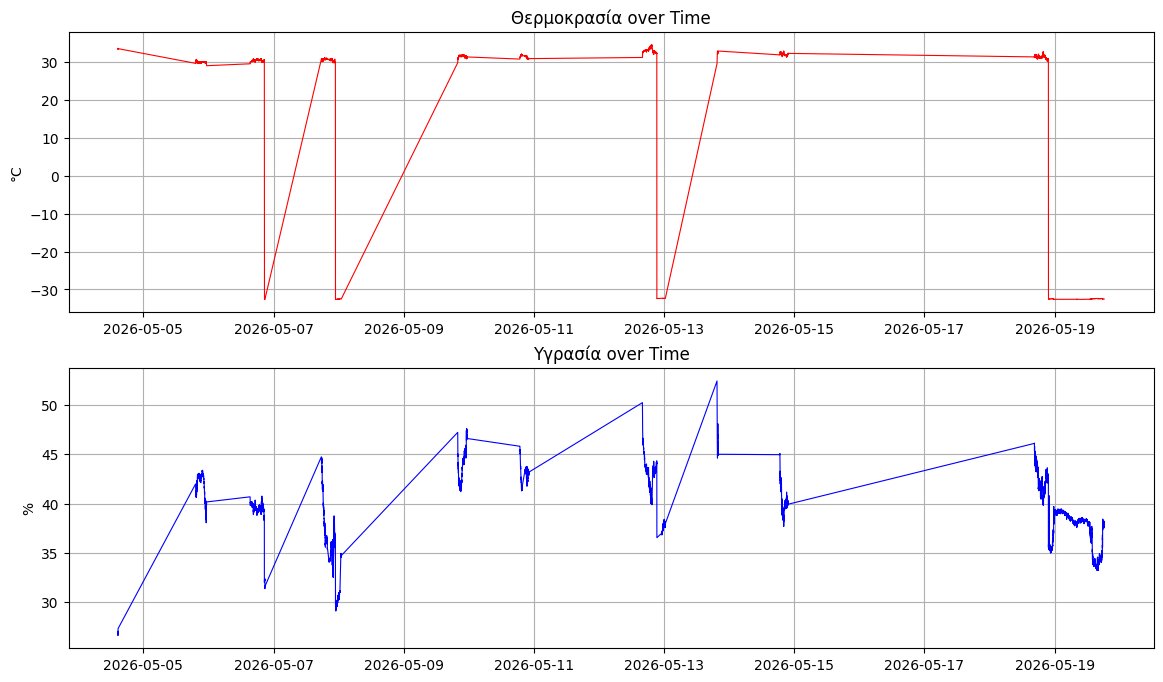

In [2]:
# Στατιστική ανάλυση
print("=== ΣΤΑΤΙΣΤΙΚΗ ΑΝΑΛΥΣΗ ΠΡΙΝ ΤΗΝ ΑΦΑΙΡΕΣΗ===")
print(df[["temperature_c", "humidity_compensated"]].describe())

# Αφαίρεση outliers
print(f"Πριν τον καθαρισμό: {len(df)} μετρήσεις")
# 10<θερμοκρασία<50
# 10<υγρασία<100
df_clean = df[
    (df["temperature_c"] > 20) & (df["temperature_c"] < 50) &
    (df["humidity_compensated"] > 10) & (df["humidity_compensated"] < 100)
].reset_index(drop=True)
# Στατιστική ανάλυση
print("=== ΣΤΑΤΙΣΤΙΚΗ ΑΝΑΛΥΣΗ ΜΕΤΑ ΤΗΝ ΑΦΑΙΡΕΣΗ===")
print(df_clean[["temperature_c", "humidity_compensated"]].describe())
print(f"Μετά τον καθαρισμό (θερμοκρασία): {len(df_clean["temperature_c"])} μετρήσεις")
print(f"Αφαιρέθηκαν: {len(df["temperature_c"]) - len(df_clean["temperature_c"])} outliers")
print(f"Μετά τον καθαρισμό (υγρασία): {len(df_clean["humidity_pct"])} μετρήσεις")
print(f"Αφαιρέθηκαν: {len(df["humidity_compensated"]) - len(df_clean["humidity_compensated"])} outliers")

# Γραφήματα
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(df["timestamp"], df["temperature_c"], color="red", linewidth=0.8)
ax1.set_title("Θερμοκρασία over Time")
ax1.set_ylabel("°C")
ax1.grid(True)

ax2.plot(df["timestamp"], df["humidity_compensated"], color="blue", linewidth=0.8)
ax2.set_title("Υγρασία over Time")
ax2.set_ylabel("%")
ax2.grid(True)

plt.show()

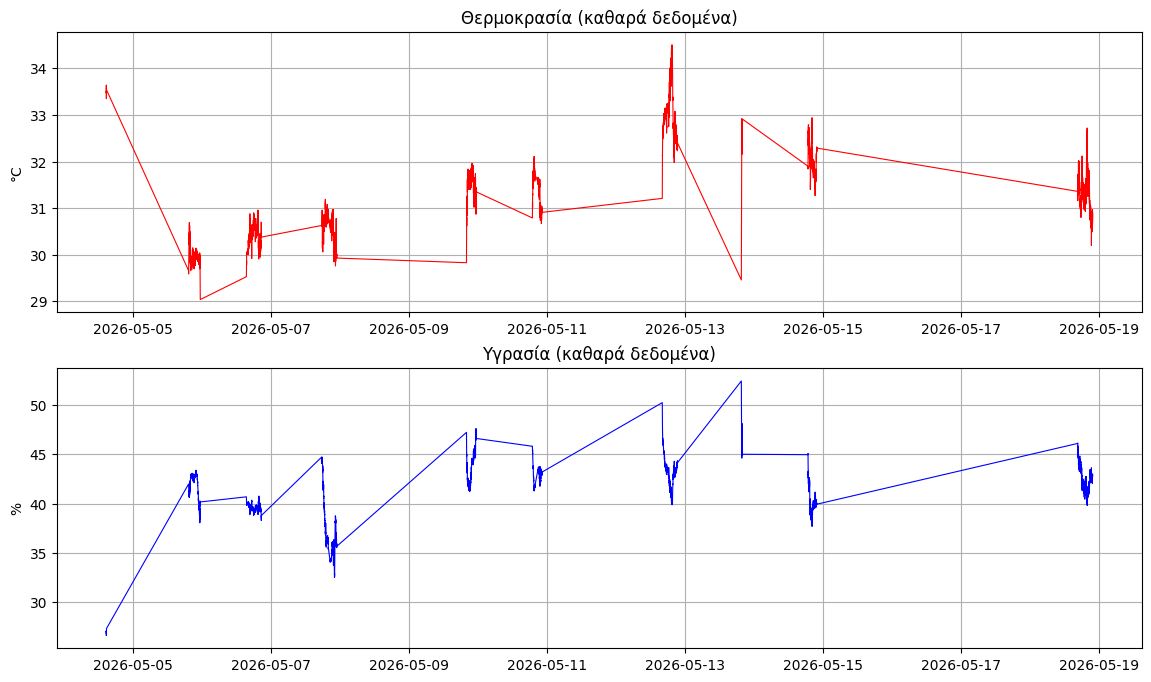

In [3]:


# Γράφημα μετά τον καθαρισμό
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(df_clean["timestamp"], df_clean["temperature_c"], color="red", linewidth=0.8)
ax1.set_title("Θερμοκρασία (καθαρά δεδομένα)")
ax1.set_ylabel("°C")
ax1.grid(True)

ax2.plot(df_clean["timestamp"], df_clean["humidity_compensated"], color="blue", linewidth=0.8)
ax2.set_title("Υγρασία (καθαρά δεδομένα)")
ax2.set_ylabel("%")
ax2.grid(True)

plt.show()

[32.06637037 30.69936982 32.17683104 ... 30.91311319 31.09575213
 32.36704669]
=== LINEAR REGRESSION - Θερμοκρασία ===
R² Score: 0.3589
RMSE: 0.8571


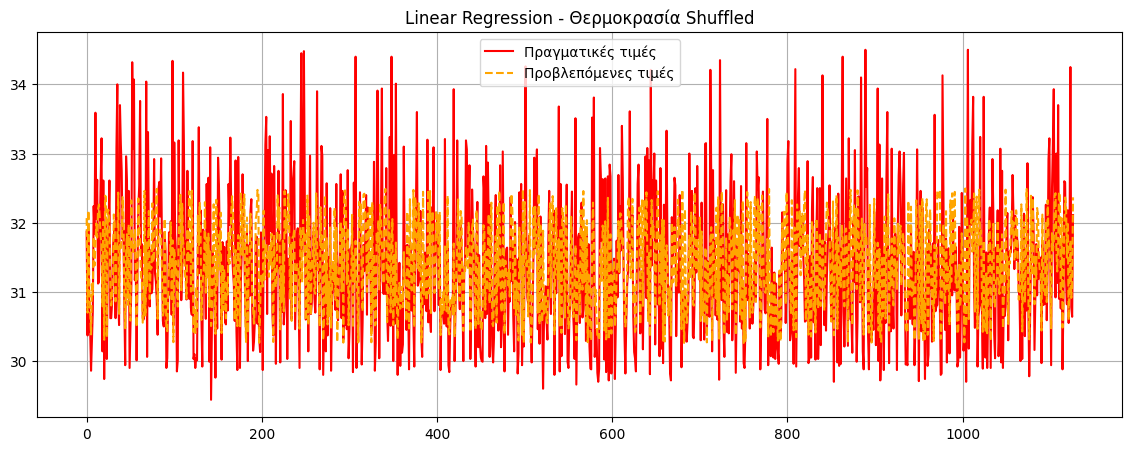

[43.26425344 43.26511137 43.2659693  ... 44.22856838 44.22942631
 44.23028424]
=== LINEAR REGRESSION - Υγρασία ===
R² Score: -1.6178
RMSE: 2.3495


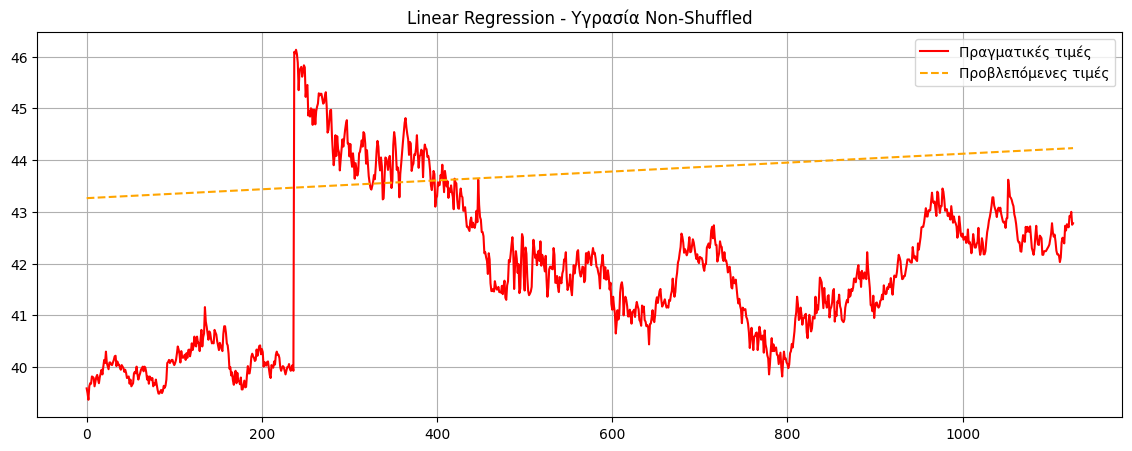

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Προετοιμασία δεδομένων
df_clean["time_idx"] = np.arange(len(df_clean))

X = df_clean[["time_idx"]]
y_temp = df_clean["temperature_c"]
y_hum = df_clean["humidity_compensated"]

# Θερμοκρασία 
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_temp, test_size=0.2, shuffle=True) 
# Shuffle True για μικρή ποσότητα δεδομένων
# Shuffle False για μεγάλη ποσότητα δεδομένων

# Εκπαίδευση μοντέλου
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(y_pred)
print("=== LINEAR REGRESSION - Θερμοκρασία ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Γράφημα
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label="Πραγματικές τιμές", color="red")
plt.plot(y_pred, label="Προβλεπόμενες τιμές", color="orange", linestyle="--")
plt.title("Linear Regression - Θερμοκρασία Shuffled")
plt.legend()
plt.grid(True)
plt.show()

# Υγρασία
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_hum, test_size=0.2, shuffle=False) 
# Shuffle True για μικρή ποσότητα δεδομένων
# Shuffle False για μεγάλη ποσότητα δεδομένων

# Εκπαίδευση μοντέλου
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(y_pred)
print("=== LINEAR REGRESSION - Υγρασία ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Γράφημα
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label="Πραγματικές τιμές", color="red")
plt.plot(y_pred, label="Προβλεπόμενες τιμές", color="orange", linestyle="--")
plt.title("Linear Regression - Υγρασία Non-Shuffled")
plt.legend()
plt.grid(True)
plt.show()

=== ARIMA - Πρόβλεψη Θερμοκρασίας ===
[31.34 31.34 31.35 31.35 31.34 31.34 31.35 31.35 31.35 31.35 31.35 31.35
 31.35 31.35 31.35 31.35 31.35 31.35 31.35 31.35]


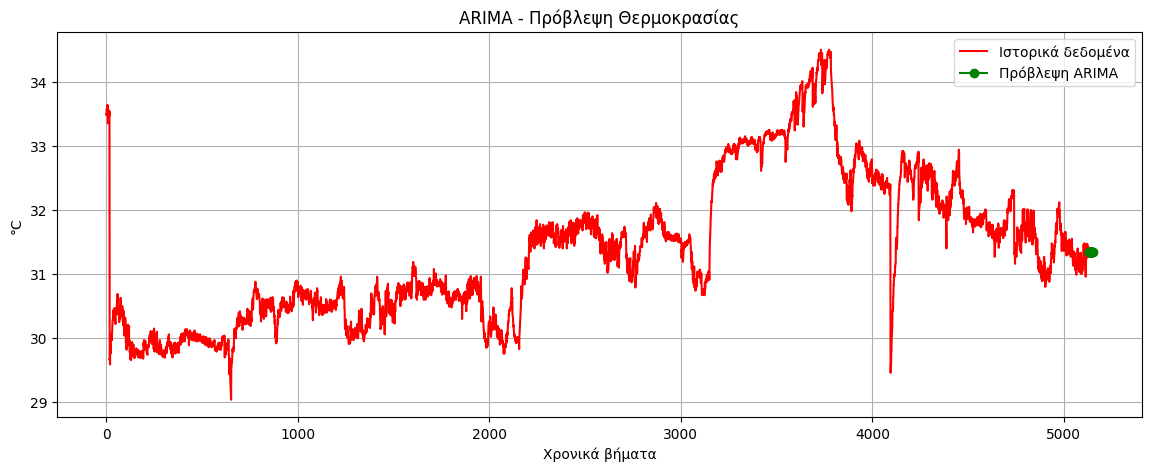

=== ARIMA - Πρόβλεψη Υγρασίας ===
[40.97 40.98 40.99 40.98 40.98 40.99 40.98 40.98 40.98 40.99 40.99 40.98
 40.98 40.98 40.98 40.98 40.98 40.98 40.98 40.98]


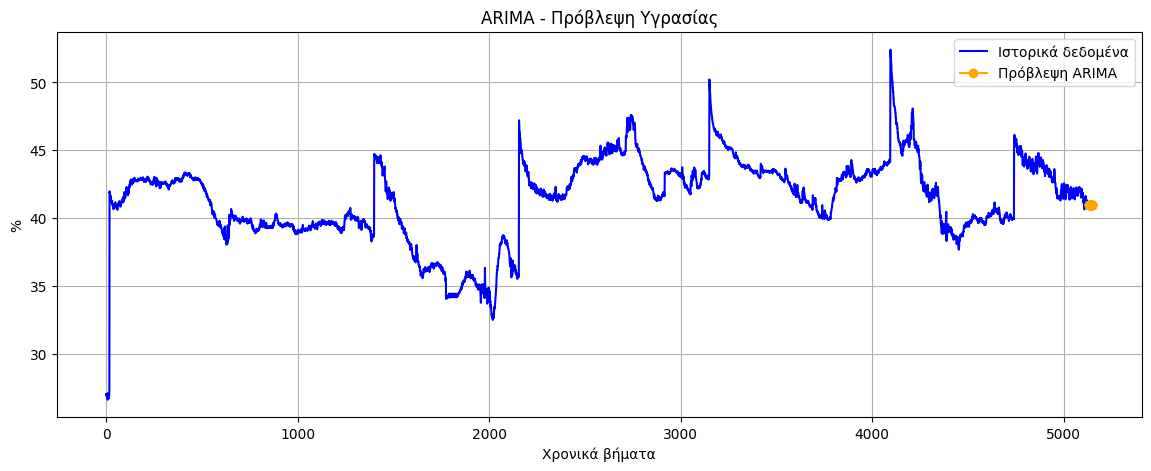

In [5]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

#Υποσύνολο για ταχύτητα
series_temp = df_clean["temperature_c"].values[:-500]
series_hum  = df_clean["humidity_compensated"].values[:-500]

# === ARIMA Θερμοκρασία ===
model_temp = ARIMA(series_temp, order=(7, 1, 0))
fit_temp   = model_temp.fit()
forecast_temp = fit_temp.forecast(steps=20)

print("=== ARIMA - Πρόβλεψη Θερμοκρασίας ===")
print(forecast_temp.round(2))

plt.figure(figsize=(14, 5))
plt.plot(range(len(series_temp)), series_temp, label="Ιστορικά δεδομένα", color="red")
plt.plot(range(len(series_temp), len(series_temp)+20), forecast_temp,
         label="Πρόβλεψη ARIMA", color="green", marker="o")
plt.title("ARIMA - Πρόβλεψη Θερμοκρασίας")
plt.xlabel("Χρονικά βήματα")
plt.ylabel("°C")
plt.legend()
plt.grid(True)
plt.show()

# === ARIMA Υγρασία ===
model_hum = ARIMA(series_hum, order=(10, 1, 0))
fit_hum   = model_hum.fit()
forecast_hum = fit_hum.forecast(steps=20)

print("=== ARIMA - Πρόβλεψη Υγρασίας ===")
print(forecast_hum.round(2))

plt.figure(figsize=(14, 5))
plt.plot(range(len(series_hum)), series_hum, label="Ιστορικά δεδομένα", color="blue")
plt.plot(range(len(series_hum), len(series_hum)+20), forecast_hum,
         label="Πρόβλεψη ARIMA", color="orange", marker="o")
plt.title("ARIMA - Πρόβλεψη Υγρασίας")
plt.xlabel("Χρονικά βήματα")
plt.ylabel("%")
plt.legend()
plt.grid(True)
plt.show()